In [1]:
#IMPORTACION DE LIBRERIAS
import tensorflow as tf
from tensorflow import keras

import matplotlib.pyplot as plt

In [2]:
#CARGA Y PREPROCESAMIENTO DE DATOS
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [3]:
#OBTENER EL TAMAÑO DE LA IMAGEN
print(f"Training images shape: {x_train.shape[1:]} (height, width, channels)")
print(f"Test images shape: {x_test.shape[1:]} (height, width, channels)")

Training images shape: (32, 32, 3) (height, width, channels)
Test images shape: (32, 32, 3) (height, width, channels)


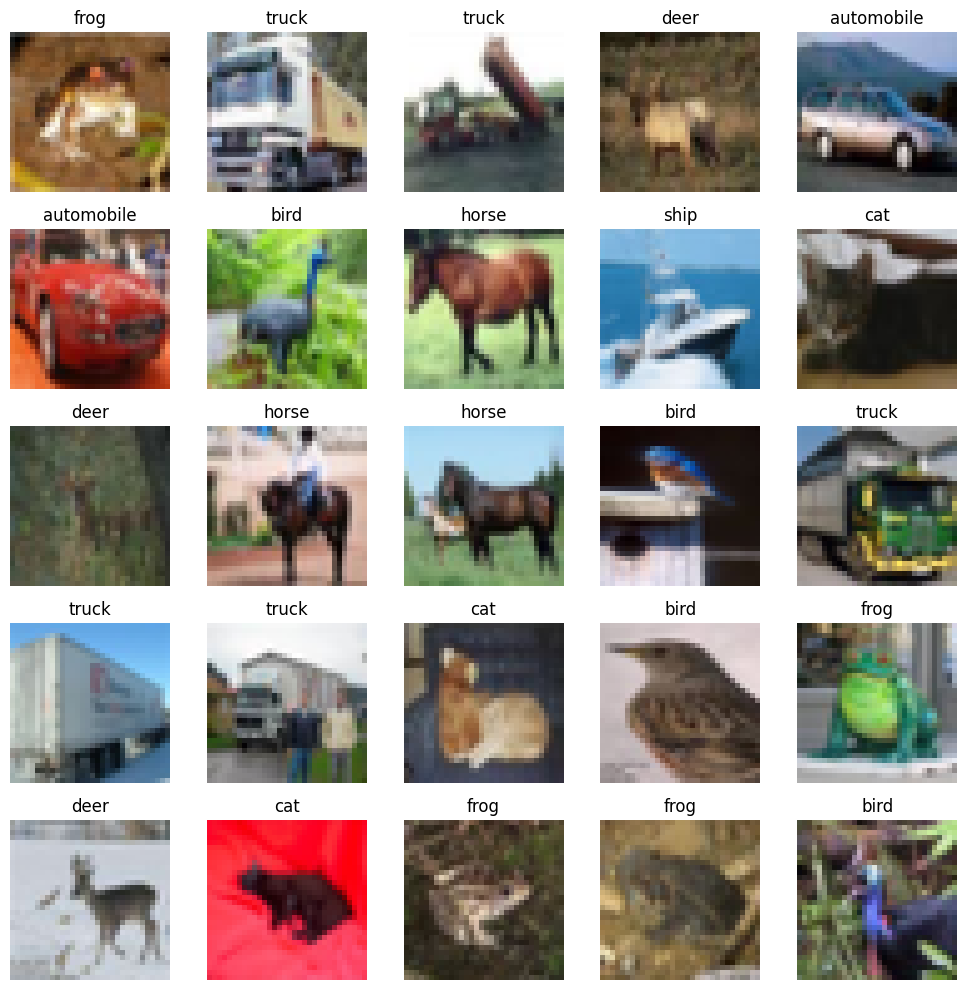

In [4]:
#VISUALIZACION DE IMAGENES DEL CONJUNTO DE ENTRENAMIENTO
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [5]:
# MODELO BÁSICO CNN: 3 capas convolucionales (3x3) + max pooling (2x2) con ReLU
model = keras.Sequential([
	keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=x_train.shape[1:]),
	keras.layers.MaxPooling2D((2, 2)),

	keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
	keras.layers.MaxPooling2D((2, 2)),

	keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
	keras.layers.MaxPooling2D((2, 2)),

	keras.layers.Flatten(),
	keras.layers.Dense(128, activation='relu'),
	keras.layers.Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
#COMPILACION Y ENTRENAMIENTO DEL MODELO
model.compile(
	optimizer='adam',
	loss=keras.losses.SparseCategoricalCrossentropy(),
	metrics=['accuracy']
)

history = model.fit(
	x_train, y_train,
	epochs=30,
	validation_data=(x_test, y_test)
)

Epoch 1/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - accuracy: 0.5012 - loss: 1.3763 - val_accuracy: 0.6158 - val_loss: 1.0751
Epoch 2/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6673 - loss: 0.9443 - val_accuracy: 0.6700 - val_loss: 0.9394
Epoch 3/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7292 - loss: 0.7762 - val_accuracy: 0.6964 - val_loss: 0.8882
Epoch 4/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7649 - loss: 0.6737 - val_accuracy: 0.7305 - val_loss: 0.7961
Epoch 5/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7907 - loss: 0.5934 - val_accuracy: 0.7399 - val_loss: 0.7854
Epoch 6/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8189 - loss: 0.5159 - val_accuracy: 0.7559 - val_loss: 0.7480
Epoch 7/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8410 - loss: 0.4494 - val_accuracy: 0.7430 - val_loss: 0.8238
Epoch 8/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8606 - loss: 0.3924 

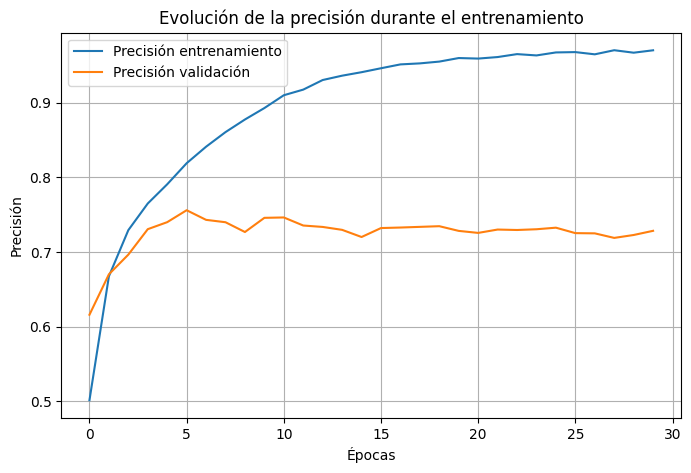

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7283 - loss: 2.0136
Pérdida final en test: 2.0136
Precisión final en test: 0.7283


In [7]:
# Gráfica de precisión en entrenamiento y validación
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Precisión entrenamiento')
plt.plot(history.history['val_accuracy'], label='Precisión validación')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.title('Evolución de la precisión durante el entrenamiento')
plt.legend()
plt.grid(True)
plt.show()

# Evaluación final en el conjunto de prueba
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=1)
print(f"Pérdida final en test: {test_loss:.4f}")
print(f"Precisión final en test: {test_accuracy:.4f}")

In [8]:
print(f"Precisión final en el conjunto de prueba: {test_accuracy:.4f}")
print(f"Precisión final en porcentaje: {test_accuracy * 100:.2f}%")

Precisión final en el conjunto de prueba: 0.7283
Precisión final en porcentaje: 72.83%


44460/44460 ━━━━━━━━━━━━━━━━━━━━ 0s 3us/step


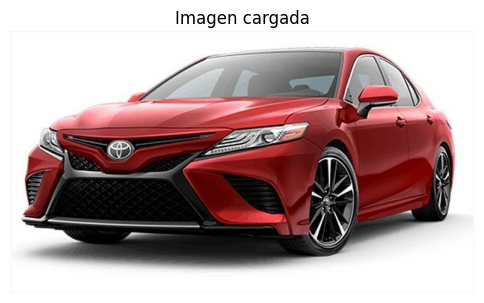

In [10]:
# Carga la imagen desde la URL seleccionada y muéstrala
url = "https://www.repuestosautomotrices.com/wp-content/uploads/2023/09/automovil-2.jpg"

img_path = keras.utils.get_file("imagen_url.jpg", origin=url)
img = keras.utils.load_img(img_path)

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis("off")
plt.title("Imagen cargada")
plt.show()

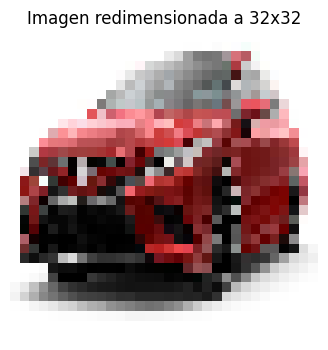

In [11]:
# Redimensionar la imagen cargada a 32x32 pixeles
img_resized = keras.utils.load_img(img_path, target_size=(32, 32))

# Mostrar la imagen redimensionada
plt.figure(figsize=(4, 4))
plt.imshow(img_resized)
plt.axis("off")
plt.title("Imagen redimensionada a 32x32")
plt.show()

In [12]:
# Convertir la imagen a arreglo NumPy
img_array = keras.utils.img_to_array(img_resized)

# Normalizar la imagen
img_array = img_array / 255.0

# Añadir dimensión de batch
img_array = img_array[None, ...]

print(f"Forma de la imagen preparada: {img_array.shape}")

Forma de la imagen preparada: (1, 32, 32, 3)


In [13]:
# Predicción de la clase para la imagen preparada (img_array)
predicciones = model.predict(img_array)
clase_predicha = predicciones.argmax(axis=1)[0]
confianza = predicciones[0][clase_predicha]

print(f"Clase predicha: {class_names[clase_predicha]}")
print(f"Confianza: {confianza:.4f} ({confianza*100:.2f}%)")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 681ms/step
Clase predicha: automobile
Confianza: 0.9730 (97.30%)


In [14]:
# Mostrar el resultado de la predicción según el diccionario de clases
print(f"Clase predicha (índice): {clase_predicha}")
print(f"Clase predicha (nombre): {class_names[clase_predicha]}")
print(f"Confianza: {confianza:.4f} ({confianza * 100:.2f}%)")

Clase predicha (índice): 1
Clase predicha (nombre): automobile
Confianza: 0.9730 (97.30%)


In [15]:
# Guardar el modelo en formato nativo de Keras (.keras)
model.save("modelo_cifar10.keras")
print("Modelo guardado como 'modelo_cifar10.keras'")

Modelo guardado como 'modelo_cifar10.keras'


In [ ]:
# Cargar el modelo guardado en formato .keras
model = keras.models.load_model("modelo_cifar10.keras")
print("Modelo cargado correctamente desde 'modelo_cifar10.keras'")